<a href="https://colab.research.google.com/github/vivekjain060305-coder/Wine_Quality_Prerdiction/blob/main/WQP_Decission_tree_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving wine-quality-white-and-red (1).csv to wine-quality-white-and-red (1) (1).csv

Results for 70-30 Split
Accuracy: 83.58974358974359
Precision Score: 0.5743073047858942
F1 Score: 0.5876288659793815
AUC Score: 0.7470041601655333


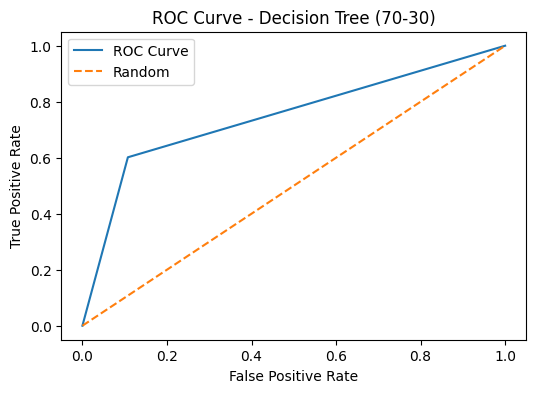

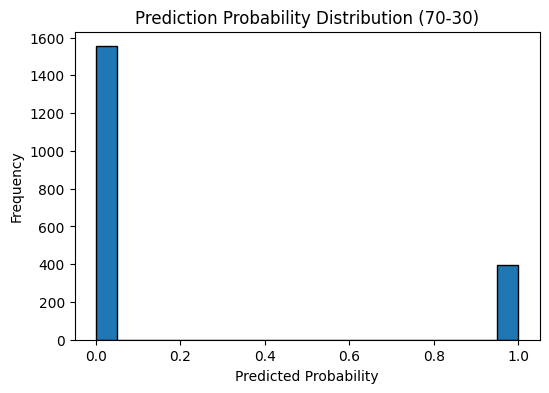


Results for 80-20 Split
Accuracy: 84.92307692307692
Precision Score: 0.6153846153846154
F1 Score: 0.608
AUC Score: 0.7550275396295081


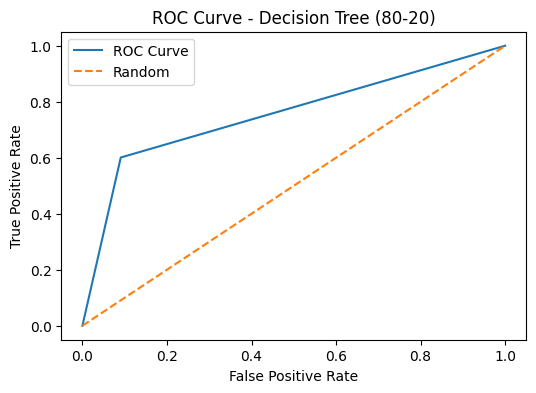

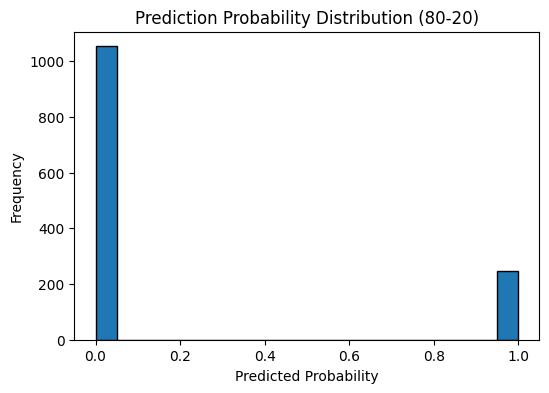

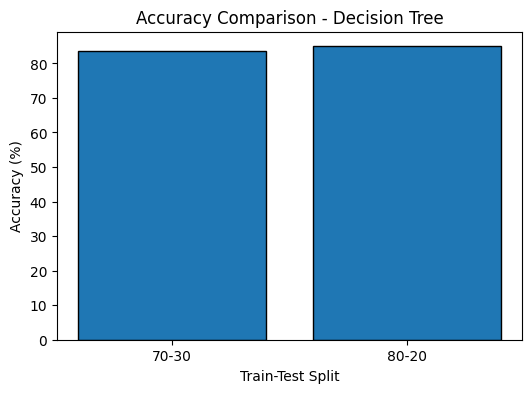

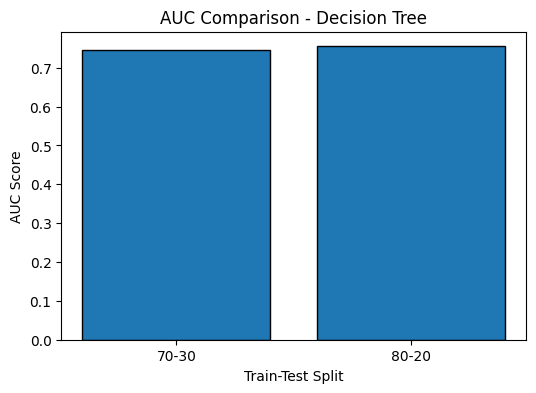

In [2]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, precision_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score

# Step 2: Upload dataset
from google.colab import files
uploaded = files.upload()

# Step 3: Load dataset
df = pd.read_csv("wine-quality-white-and-red (1).csv")

# Step 4: Create binary classification label
df["quality_label"] = (df["quality"] >= 7).astype(int)

# Step 5: Define features and target
X = df.drop(["quality", "quality_label"], axis=1)
y = df["quality_label"]

# Identify categorical and numerical features
categorical_features = ['type']
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# Step 6: Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Step 7: Define splits
splits = {
    "70-30": 0.3,
    "80-20": 0.2
}

# Lists to store results
split_names = []
accuracy_list = []
auc_list = []
precision_list = []
f1_list = []

# Step 8: Run for both splits
for split_name, test_size in splits.items():
    print("\n==============================")
    print(f"Results for {split_name} Split")
    print("==============================")

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # Create model pipeline
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ])

    # Train model
    model_pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = model_pipeline.predict(X_test)
    y_pred_prob = model_pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred) * 100
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_prob)

    print("Accuracy:", accuracy)
    print("Precision Score:", precision)
    print("F1 Score:", f1)
    print("AUC Score:", auc_score)

    # Store values
    split_names.append(split_name)
    accuracy_list.append(accuracy)
    precision_list.append(precision)
    f1_list.append(f1)
    auc_list.append(auc_score)

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label="ROC Curve")
    plt.plot([0, 1], [0, 1], linestyle='--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - Decision Tree ({split_name})")
    plt.legend()
    plt.show()

    # Prediction probability distribution graph
    plt.figure(figsize=(6, 4))
    plt.hist(y_pred_prob, bins=20, edgecolor='black')
    plt.xlabel("Predicted Probability")
    plt.ylabel("Frequency")
    plt.title(f"Prediction Probability Distribution ({split_name})")
    plt.show()

# Step 9: Accuracy comparison graph
plt.figure(figsize=(6, 4))
plt.bar(split_names, accuracy_list, edgecolor='black')
plt.xlabel("Train-Test Split")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison - Decision Tree")
plt.show()

# Step 10: AUC comparison graph
plt.figure(figsize=(6, 4))
plt.bar(split_names, auc_list, edgecolor='black')
plt.xlabel("Train-Test Split")
plt.ylabel("AUC Score")
plt.title("AUC Comparison - Decision Tree")
plt.show()